<h1><center>Laboratorio 7: Ensamblaje, Optimización de Hiperparámetros e Interpretabilidad 🤖</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos</strong></center>

---

### Cuerpo Docente

- Profesores: Pablo Badilla y Diego Cortez
- Auxiliares: Valentina Rojas y Melanie Peña
- Ayudantes: Javiera Arévalo, Tamara Carrasco y Ignacio Reyes

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Ignacio Díaz C.
- Nombre de alumno 2: Benjamín Fuentes R.

---

### Reglas

- **Grupos de 2 personas**
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Prohibido copiar.
- Uso de LLM (Copilot, Claude, Antigravity, Cursor, etc.) restringido a consultas, documentación y corrección de errores.

## Temas a tratar

- Ensamblaje: Bagging (`RandomForest`), Boosting (`XGBoost`, `LightGBM`) y Stacking.
- Optimización de Hiperparámetros con `Optuna` y visualización interactiva con `optuna-dashboard`.
- Interpretabilidad global: `Permutation Feature Importance (PFI)`.
- Interpretabilidad local: `SHAP`.

### Objetivos principales del laboratorio

- Aplicar y comparar métodos de ensamblaje sobre un problema de clasificación de texto.
- Optimizar hiperparámetros de LightGBM usando Optuna y visualizar el proceso con `optuna-dashboard`.
- Interpretar las predicciones del modelo usando PFI y SHAP.

El laboratorio deberá ser desarrollado sin el uso indiscriminado de iteradores nativos de Python (aka "for", "while"). La idea es que aprendan a exprimir al máximo las funciones optimizadas que nos entrega `pandas`.

### Instalamos librerías 😸

In [1]:
!uv add nltk lightgbm xgboost optuna shap scikit-learn plotly

Resolved 149 packages in 9ms
Audited 141 packages in 15ms


In [2]:
import warnings

import matplotlib.pyplot as plt
import nltk
import numpy as np
import optuna
import pandas as pd
import shap
from lightgbm import LGBMClassifier
from nltk import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split  # noqa: F401
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from optuna.visualization import (
    plot_parallel_coordinate,
    plot_optimization_history,
    plot_param_importances,
)
import plotly.express as px
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

RANDOM_STATE = 42
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 1. ¿Quién es Bat Cow?

<p align="center">
  <img src="https://i.imgur.com/D9f1RHy.jpg" width="350">
</p>

En vez de estar desarrollando las evaluaciones correspondientes a su curso, su profesor de catedra y su auxiliar discuten acerca la alineación (i.e., si es heroe o villano) del personaje de ficción Bat-Cow.

El cuerpo docente, no logra ponerse de acuerdo si el personaje es bueno, neutral o malo: el auxiliar plantea que Bat-cow posee una siniestra mirada, intrigante pero común característica de los personajes malvados.
Por otra parte, extendiendo las ideas de Rousseau, el profesor plantea que tal como los humanos no nacen malos, no existe motivo por el cual una vaca con superpoderes deba serlo.

Sin embargo, ambos concuerdan que es difícil estimar la alineación solo usando los atributos físicos. Es por esto que les solicitan construir y optimizar un clasificador basado en texto que analice la alineación de cada personaje basado en su historia personal.

Para este laboratorio deben trabajar con los datos `df_comics.csv` y `comics_no_label.csv` subidos a u-cursos.

In [3]:
df_comics = pd.read_csv("df_comics.csv", index_col=0)
df_comics_no_label = pd.read_csv("comics_no_label.csv", index_col=0)
df_comics = df_comics.dropna(subset=["history_text"])
df_comics

,name,real_name,full_name,overall_score,history_text,powers_text,intelligence_score,strength_score,speed_score,durability_score,...,has_flight,has_accelerated_healing,has_weapons_master,has_intelligence,has_reflexes,has_super_speed,has_durability,has_stamina,has_agility,has_super_strength
0,3-D Man,"Delroy Garrett, Jr.","Delroy Garrett, Jr.",6,"Delroy Garrett, Jr. grew up to become a track ...",NaN,85,30,60,60,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,A-Bomb,Richard Milhouse Jones,Richard Milhouse Jones,20,"Richard ""Rick"" Jones was orphaned at a young ...","On rare occasions, and through unusual circu...",80,100,80,100,...,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
3,Aa,Aa,NaN,12,Aa is one of the more passive members of the P...,NaN,80,50,55,45,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Aaron Cash,Aaron Cash,Aaron Cash,5,Aaron Cash is the head of security at Arkham A...,NaN,80,10,25,40,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,Aayla Secura,Aayla Secura,NaN,8,ayla Secura was a Rutian Twi'lek Jedi Knight (...,NaN,90,40,45,55,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1445,Zatanna,Zatanna Zatara,Zatanna Zatara,10,Zatanna is the daughter of adventurer John Zat...,Zatanna is genetically talented with her magi...,90,10,25,30,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1446,Zero,DWN-∞: Zero,DWN-∞: Zero,18,Zero was created by the late Dr. Albert Wily ...,NaN,80,100,100,100,...,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1447,Zoom (New 52),Hunter Zolomon,NaN,20,"Hunter Zolomon is better known as Zoom, a spee...",After tricking Barry Allen and Wally West into...,95,50,100,75,...,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1448,Zoom,Hunter Zolomon,Hunter Zolomon,9,Hunter Zolomon had a troubled relationship wi...,"Zoom is able to alter time, to make himself ev...",75,10,100,30,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


## 1.1 Obtención de Features y Bag of Words

<p align="center">
  <img src="https://media0.giphy.com/media/eIUpSyzwGp0YhAMTKr/200.gif" width="300">
</p>

`bag of words` es un modelo de conteo utilizado en NLP que genera una representación vectorial para cada documento a través del conteo de las palabras que contienen.

<p align="center">
  <img src="https://user.oc-static.com/upload/2020/10/23/16034397439042_surfin%20bird%20bow.png" width="500">
</p>

Para facilitar el conteo transformamos cada documento en un vector mediante **tokenización**:

In [4]:
docs = ["The teacher rocks like a good rock & roll", "the rock is the best actor in the world"]
docs_tokenizados = [word_tokenize(doc) for doc in docs]
docs_tokenizados

[['The', 'teacher', 'rocks', 'like', 'a', 'good', 'rock', '&', 'roll'],
 ['the', 'rock', 'is', 'the', 'best', 'actor', 'in', 'the', 'world']]

Podemos mejorar la tokenización con:

- **Stemming**: transforma palabras a su forma raíz (*running → run*, *rocks → rock*).
- **Eliminación de Stopwords**: elimina palabras muy frecuentes que entorpecen la clasificación (*the*, *is*, *a*, ...).

<p align="center">
  <img src="https://devopedia.org/images/article/218/8583.1569386710.png" width="300">
</p>

In [5]:
stop_words = stopwords.words("english")


class StemmerTokenizer:
    def __init__(self):
        self.ps = PorterStemmer()

    def __call__(self, doc):
        doc_tok = word_tokenize(doc)
        doc_tok = [t for t in doc_tok if t not in stop_words]
        return [self.ps.stem(t) for t in doc_tok]


tokenizador = StemmerTokenizer()

docs = [
    "The teacher rocks like a good rock & roll",
    "the rock is the best actor in the world",
    "New York is a beautiful city",
]

print("Con StemmerTokenizer:")
print([tokenizador(doc) for doc in docs])
print("\nSin preprocesamiento:")
print([word_tokenize(doc) for doc in docs])

Con StemmerTokenizer:
[['the', 'teacher', 'rock', 'like', 'good', 'rock', '&', 'roll'], ['rock', 'best', 'actor', 'world'], ['new', 'york', 'beauti', 'citi']]

Sin preprocesamiento:
[['The', 'teacher', 'rocks', 'like', 'a', 'good', 'rock', '&', 'roll'], ['the', 'rock', 'is', 'the', 'best', 'actor', 'in', 'the', 'world'], ['New', 'York', 'is', 'a', 'beautiful', 'city']]


#### Al Estilo Scikit

Scikit implementa `bag of words` con `CountVectorizer()`. Además soporta **n-gramas**: secuencias contiguas de n palabras que se tratan como un único token. Esto permite capturar contexto local que los unigramas pierden.

| Tipo | n | Tokens de `"nueva york ciudad"` |
|------|---|--------------------------------|
| Unigrama | 1 | `nueva`, `york`, `ciudad` |
| Bigrama | 2 | `nueva york`, `york ciudad` |
| Trigrama | 3 | `nueva york ciudad` |

Con `ngram_range=(1,2)` el vectorizador incluye **unigramas y bigramas** simultáneamente. Los bigramas son especialmente útiles para capturar expresiones compuestas como `bat cow`, `spider man` o `super hero` que pierden su significado si se separan.

El parámetro `max_features` limita el vocabulario a los n tokens más frecuentes, controlando la dimensionalidad de la representación.

In [6]:
bow = CountVectorizer(tokenizer=StemmerTokenizer(), ngram_range=(1, 2))
df_bow = bow.fit_transform(docs)
pd.DataFrame(df_bow.toarray(), columns=bow.get_feature_names_out())

,&,& roll,actor,actor world,beauti,beauti citi,best,best actor,citi,good,...,rock,rock &,rock best,rock like,roll,teacher,teacher rock,world,york,york beauti
0,1,1,0,0,0,0,0,0,0,1,...,2,1,0,1,1,1,1,0,0,0
1,0,0,1,1,0,0,1,1,0,0,...,1,0,1,0,0,0,0,1,0,0
2,0,0,0,0,1,1,0,0,1,0,...,0,0,0,0,0,0,0,0,1,1


#### Combinando Features: `ColumnTransformer`

Para combinar en un solo paso el preprocesamiento de texto y numérico, usamos `ColumnTransformer`. Este aplica transformadores distintos a subconjuntos de columnas del DataFrame y concatena el resultado en una sola matriz de features lista para entrenar.

<p align="center">
  <img src="https://c.tenor.com/LkQzw7k5DV4AAAAd/anime-hacking.gif" width="300">
</p>

El `preprocessing_transformer` que usaremos a lo largo del lab combina:

- **`CountVectorizer`** con `StemmerTokenizer`, `ngram_range=(1,2)` y `max_features=500` → aplicado sobre la columna `history_text`.
- **`MinMaxScaler`** → aplicado sobre los 6 atributos numéricos de habilidad: `intelligence_score`, `strength_score`, `speed_score`, `durability_score`, `power_score`, `combat_score`.

In [7]:
preprocessing_transformer = ColumnTransformer(
    transformers=[
        (
            "MinMaxScaler",
            MinMaxScaler(),
            [
                "intelligence_score",
                "strength_score",
                "speed_score",
                "durability_score",
                "power_score",
                "combat_score",
            ],
        ),
        (
            "bow",
            CountVectorizer(
                tokenizer=StemmerTokenizer(),
                max_features=500,
                ngram_range=(1, 2),
            ),
            "history_text",
        ),
    ]
)

## 1.2 Diseño de Baseline y Primer Entrenamiento [1 Punto]

<p align="center">
  <img src="https://pa1.narvii.com/6374/9eaec1b7bf9157334151452a669516f9a78b954c_hq.gif" width="300">
</p>

### 1.2.1 ¿Qué es un Baseline? [0.2 Puntos]

Antes de entrenar modelos complejos, es fundamental establecer un punto de referencia mínimo. Responde las siguientes preguntas con tus propias palabras:

1. **¿Qué es un baseline en Machine Learning?** ¿Para qué sirve establecerlo antes de evaluar modelos más sofisticados?
2. **¿Por qué usamos un `DummyClassifier` como baseline?** ¿Qué implica que un modelo "real" no logre superar su rendimiento?

> **Respuesta:**

1. Un baseline es el modelo de partida en el proceso de resolución de un problema de Machine Learning. Su objetivo es ser un modelo de referencia que resuelva el problema de forma sencilla, de tal forma de tener un punto de comparación en los resultados de cualquier implementación más compleja.
2. DummyClassifier es un modelo que clasifica de forma aleatoria, ignorando cualquier información de entrada. Su utilidad como baseline radica en saber si los modelos que estamos implementando son mejores que una clasificación aleatoria. Si no logran superar el rendimiento de DummyClassifier, significa que su implementación no vale la pena al ser superados por un modelo más sencillo que no usa la información de entrada y clasifica aleatoriamente.

---

### 1.2.2 Implementación [0.6 Puntos]

Genere un `Pipeline` con las características de 1.1 y un `DecisionTreeClassifier()` por defecto.

Separe el dataset en entrenamiento/prueba (80/20, estratificado, `random_state=RANDOM_STATE`). Entrene, reporte `classification_report` y compare con un `DummyClassifier(strategy="stratified")`.

**To-do:**
- [ ] Pipeline con preprocesamiento → `DecisionTreeClassifier`.
- [ ] Holdout estratificado 80/20.
- [ ] `classification_report` del baseline.
- [ ] Entrenar `DummyClassifier` y comparar.

In [8]:
# Pipeline con preprocesamiento -> DecisionTreeClassifier.

# Clasificador de arbol de decisión.
pipeline_DTC = Pipeline(
    [("Preprocesamiento", preprocessing_transformer),
     ("Clasificador", DecisionTreeClassifier(random_state = RANDOM_STATE))
     ]
)


# Clasificador dummy.
pipeline_Dummy = Pipeline(
    [("Preprocesamiento", preprocessing_transformer),
     ("Clasificador", DummyClassifier(strategy = "stratified", random_state = RANDOM_STATE))
     ]
)

In [9]:
# Holdout estratificado 80/20.

# Se separa las características de la etiqueta.
X = df_comics.drop(columns = ["alignment"]).copy()
y = df_comics["alignment"].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = RANDOM_STATE)

In [10]:
# Entrenamiento y evaluación del modelo Dummy.
pipeline_Dummy.fit(X_train, y_train)
predict_test_dummy = pipeline_Dummy.predict(X_test)

# Resultados de predicciones sobre conjunto de prueba.
print(classification_report(y_test, predict_test_dummy))

              precision    recall  f1-score   support

         Bad       0.32      0.34      0.33        86
        Good       0.58      0.56      0.57       148
     Neutral       0.12      0.13      0.12        23

    accuracy                           0.45       257
   macro avg       0.34      0.34      0.34       257
weighted avg       0.46      0.45      0.45       257



In [11]:
# Entrenamiento y evaluación del modelo de arbol de decisión.
pipeline_DTC.fit(X_train, y_train)
predict_test_DTC = pipeline_DTC.predict(X_test)

# Resultados de predicciones sobre conjunto de prueba.
print(classification_report(y_test, predict_test_DTC))

              precision    recall  f1-score   support

         Bad       0.41      0.43      0.42        86
        Good       0.66      0.61      0.64       148
     Neutral       0.10      0.13      0.11        23

    accuracy                           0.51       257
   macro avg       0.39      0.39      0.39       257
weighted avg       0.53      0.51      0.52       257



### 1.2.3 Pregunta de Cierre [0.2 Puntos]

**Pregunta:** ¿El `DecisionTreeClassifier` supera al `DummyClassifier`? ¿Qué concluyes de esto sobre lo que ha aprendido el modelo? Además responde:

1. ¿Por qué el accuracy puede ser una métrica engañosa en este problema? ¿Qué métrica es más apropiada si las clases están desbalanceadas?
2. ¿Por qué se usa el parámetro `stratify` en el `train_test_split`? ¿Qué problema evitamos al usarlo?
3. ¿Es mejor el clasificador que su versión aleatoria? ¿Podemos avanzar con confianza de que estamos clasificando mejor que si por ejemplo, tiraramos un dado con 3 caras?

> **Respuesta:**

In [12]:
# Se revisa el desbalance de las clases.
y.value_counts()

alignment
Good       743
Bad        429
Neutral    113
Name: count, dtype: int64

Se puede observar que en temas generales el arbol de decisión supera el clasificador dummy, ya que supera el accuracy y los promedios macro y ponderados, sin embargo, falla para la clase Neutral, ya que su precision, recall y f1-score es muy similar o hasta peor, lo que da a entender que el clasificador de arbol de decisión logra identificar a aquellos personajes buenos y malos pero no a los neutrales.

1. La métrica accuracy es engañosa en este problema porque las clases están claramente desbalanceadas. Si el modelo identifica mucho mejor la clase mayoritaria, el accuracy puede llegar a ser muy alto a pesar de tal vez fallar siempre en una clase de menor tamaño. Para estos casos, es mejor utilizar la métrica f1-score, que es una combinación entre precision y recall y ambos evalúan cierto comportamiento en la predicción de una clase particular. Comparando el promedio macro y ponderado se puede ver como se comporta el modelo teniendo en cuenta el desbalance. Mientras que el promedio macro le da el mismo peso a cada clase y baja si varias clases fallan, el promedio ponderado le da más importancia a aquellas con mas ejemplos y baja más si fallan aquellas clases más grandes.
2. Cuando se separa el conjunto de entrenamiento del de prueba utilizando el método train_test_split, se asigna de forma aleatoria cada ejemplo a cada conjunto. Esto es problemático porque existe la posibilidad de desbalancecon respecto a la distribución inicial, por esa razón, se usa stratify = y, que asigna cada ejemplo a cada conjunto teniendo en cuenta esa distribución inicial de las clases y evita que el tamaño de las clases sean diferentes entre el conjunto de entrenamiento y prueba.
3. En general, el clasificador es mejor que tirar un dado de 3 caras, pero como se mencionó antes, falla en la clase Neutral.

---

# 2. Métodos de Ensamblaje [2 Puntos]

<p align="center">
  <img src="https://media.giphy.com/media/l0HlHFRbmaZtBRhXG/giphy.gif" width="300">
</p>

Los métodos de ensamblaje combinan múltiples modelos para obtener predicciones más robustas. Exploraremos tres estrategias:

| Estrategia | Idea clave | Ejemplo |
|------------|-----------|---------|
| **Bagging** | Modelos en paralelo sobre subconjuntos aleatorios | Random Forest |
| **Boosting** | Modelos en secuencia, cada uno corrige al anterior | XGBoost, LightGBM |
| **Stacking** | Predicciones de modelos base como input de un meta-modelo | StackingClassifier |

Todos usarán el mismo `preprocessing_transformer` de la sección 1.

## 2.1 Bagging: Random Forest [0.5 Puntos]

### 2.1.1 Descripción del algoritmo [0.2 Puntos]

Describe con tus propias palabras cómo funciona el **Bagging (Bootstrap Aggregating)**. La descripción debe cubrir los siguientes tres pasos:

1. **Generación de subconjuntos**: ¿Cómo se obtienen los subconjuntos de entrenamiento a partir del dataset original? ¿Se usa todo el dataset en cada uno? ¿Se pueden repetir instancias?
2. **Entrenamiento**: ¿Qué se entrena sobre cada subconjunto? ¿Los modelos se entrenan de forma dependiente o independiente entre sí?
3. **Agregación**: ¿Cómo se combinan las predicciones de todos los modelos para obtener una respuesta final?

> **Respuesta:**


En los modelos de tipo Bagging, se entrenan varios modelos del mismo tipo en paralelo. Cada uno utiliza una versión distinta del conjunto de datos original, manteniendo el tamaño pero con ejemplos asignados de forma aleatoria y con repetición.

Cada modelo se entrena de forma independiente con el subconjunto de datos asignado. 

Para la predicción, cada modelo hace su predicción de forma independiente y genera un voto en la clase predicha. Para un modelo de clasificación tipo bagging, la etiqueta predicha final es aquella que recibió mayor número de votos de los modelos en paralelo.



---

### 2.1.2 Implementación [0.2 Puntos]

**To-do:**
- [ ] Pipeline con `RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)`.
- [ ] Entrenar y reportar `classification_report`.

In [13]:
# Clasificador dummy.
pipeline_RF = Pipeline(
    [("Preprocesamiento", preprocessing_transformer),
     ("Clasificador", RandomForestClassifier(n_estimators = 100, class_weight='balanced', random_state = RANDOM_STATE))
     ]
)

# class_weight='balanced' para disminuir efecto de desbalance en el entrenamiento.

In [14]:
# Entrenamiento y evaluación del modelo de arbol de decisión.
pipeline_RF.fit(X_train, y_train)
predict_test_RF = pipeline_RF.predict(X_test)

# Resultados de predicciones sobre conjunto de prueba.
print(classification_report(y_test, predict_test_RF))

              precision    recall  f1-score   support

         Bad       0.64      0.27      0.38        86
        Good       0.63      0.93      0.75       148
     Neutral       0.33      0.04      0.08        23

    accuracy                           0.63       257
   macro avg       0.53      0.41      0.40       257
weighted avg       0.61      0.63      0.56       257



### 2.1.3 Pregunta de Cierre [0.1 Puntos]

**Pregunta:** ¿El Random Forest mejoró respecto al baseline? Comenta los resultados observados en el `classification_report` y explica a qué se debe la diferencia (o falta de ella), considerando las características del algoritmo que describiste anteriormente.

> **Respuesta:**

Se puede notar que los resultados son en general mejores, mejorando el accuracy y los promedios macro y ponderados, sin embargo, la clase neutral bajo considerablemente su precisión en recall.

El paralelismo de varios modelos del mismo tipo permite generalizar mejor y mejorar la clasificación, sin embargo, esta clase de modelos (arboles de clasificación) es fuertemente afectado por el desbalance de clases y enorme dimensionalidad, y usar varios en paralelo solo incrementa el problema. El modelo probablemente encontró más eficiente clasificar menor por esa clase minoritaria al generar mejores resultados generales, lo que produce tan bajos resultados para la clase neutral, esto a pesar de usar class_weight='balanced'.

## 2.2 Boosting: XGBoost y LightGBM [0.8 Puntos]

### 2.2.1 Descripción del algoritmo [0.3 Puntos]

Describe con tus propias palabras cómo funciona el **Boosting**. Tu descripción debe cubrir los siguientes tres pasos:

1. **Entrenamiento secuencial**: ¿En qué se diferencia el Boosting del Bagging en cuanto al orden en que se entrenan los modelos? ¿Son independientes entre sí?
2. **Corrección de errores**: ¿Cómo sabe cada modelo nuevo en qué instancias debe enfocarse? ¿Qué información del modelo anterior utiliza?
3. **Predicción final**: ¿Cómo se combinan las predicciones de todos los modelos? ¿Es una votación simple o una combinación ponderada?

Además, explica brevemente en qué se diferencian **XGBoost** y **LightGBM** como implementaciones de Boosting, y por qué XGBoost requiere que las etiquetas sean numéricas mientras que LightGBM acepta strings directamente.

> **Respuesta:**

A diferencia del Bagging donde cada submodelo se entrena de forma independiente y en paralelo con un subconjunto de datos, en los modelos tipo boosting, cada submodelo se entrena y clasifica de forma secuencial. Al primer modelo se le entrega todos los datos del conjunto y aquellos ejemplos que fallan en la clasificación van al siguiente. De esta forma, cada modelo siguiente se enfoca en características cada vez más específicas.

Para clasificar, cada submodelo entrega su predicción y se suman se forma ponderada según la tasa de aprendizaje ajustada.

---

### 2.2.2 Implementación [0.4 Puntos]

**To-do:**
- [ ] Crear `LabelEncoder`, ajustarlo sobre `y_train` y transformar `y_train` e `y_test`.
- [ ] Pipeline con `XGBClassifier(random_state=RANDOM_STATE, eval_metric="mlogloss", verbosity=0)`. Reportar resultados decodificando las predicciones con `le.inverse_transform`.
- [ ] Pipeline con `LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)`. Reportar resultados.

In [15]:
# LabelEncoder.
le = LabelEncoder()

# Se ajusta y transforman los conjuntos.
le.fit(y_train)

y_train_e = le.transform(y_train)
y_test_e = le.transform(y_test)

In [16]:
# Clasificador XGB.
pipeline_XGB = Pipeline(
    [("Preprocesamiento", preprocessing_transformer),
     ("Clasificador", XGBClassifier(eval_metric = "mlogloss", class_weight='balanced', random_estate = RANDOM_STATE, verbosity = 0))
     ]
)

# Clasificador LGBM.
pipeline_LGBM = Pipeline(
    [("Preprocesamiento", preprocessing_transformer),
     ("Clasificador", LGBMClassifier(random_state = RANDOM_STATE, class_weight='balanced', verbose = -1))
     ]
)

In [17]:
# Entrenamiento y evaluación del modelo de arbol de decisión.
pipeline_XGB.fit(X_train, y_train_e)
predict_test_XGB_e = pipeline_XGB.predict(X_test)

# Se invierte el encoder de las etiquetas.
predict_test_XGB = le.inverse_transform(predict_test_XGB_e)

# Resultados de predicciones sobre conjunto de prueba.
print(classification_report(y_test, predict_test_XGB))

              precision    recall  f1-score   support

         Bad       0.55      0.42      0.47        86
        Good       0.68      0.84      0.75       148
     Neutral       0.33      0.09      0.14        23

    accuracy                           0.63       257
   macro avg       0.52      0.45      0.45       257
weighted avg       0.60      0.63      0.60       257



In [18]:
# Entrenamiento y evaluación del modelo de arbol de decisión.
pipeline_LGBM.fit(X_train, y_train_e)
predict_test_LGBM_e = pipeline_LGBM.predict(X_test)

# Se invierte el encoder de las etiquetas.
predict_test_LGBM = le.inverse_transform(predict_test_LGBM_e)

# Resultados de predicciones sobre conjunto de prueba.
print(classification_report(y_test, predict_test_LGBM))

              precision    recall  f1-score   support

         Bad       0.56      0.53      0.55        86
        Good       0.72      0.82      0.76       148
     Neutral       0.50      0.13      0.21        23

    accuracy                           0.66       257
   macro avg       0.59      0.49      0.51       257
weighted avg       0.64      0.66      0.64       257



### 2.2.3 Pregunta de Cierre [0.1 Puntos]

**Pregunta:** Compara los resultados de XGBoost y LightGBM según el `classification_report`. ¿Cuál tuvo mejor desempeño en F1-Macro? ¿Ambos mejoran respecto al baseline? Considerando las diferencias que describiste en 2.2.1, ¿a qué atribuyes las similitudes o diferencias en rendimiento?

> **Respuesta:**

Se puede observar que los resultados de ambos modelos son mejores con respecto al baseline, puesto que tienen mayor valores en accuracy y en cada uno de los promedios macro y ponderado, existiendo pequeñas mejoras para la clase neutral, aunque sigue siendo menos precisa que el resto.

En general, ambos modelos funcionan mejor que los casos anteriores porque revisan de forma específica los errores cometidos en cada secuencia, sin embargo, se puede notar que LGBM tiene mejor desempeño, particularmente por el desbalance de las clases al tener mejores resultados en la clase minoritaria.

## 2.3 Stacking [0.7 Puntos]

### 2.3.1 Descripción del algoritmo [0.2 Puntos]

Describe con tus propias palabras cómo funciona el **Stacking**. Tu descripción debe cubrir los siguientes tres aspectos:

1. **Predicciones como features**: ¿Qué rol cumplen los modelos base? ¿Sobre qué datos generan sus predicciones para ser usadas por el meta-modelo? ¿Por qué se usa validación cruzada interna en lugar de predecir directamente sobre los datos de entrenamiento?
2. **Meta-modelo**: ¿Qué recibe como input el meta-modelo y qué aprende? ¿En qué se diferencia su rol del de los modelos base?
3. **Ventaja sobre selección simple**: ¿Por qué el Stacking puede superar a cualquier modelo base individual? ¿Qué aprovecha de la diversidad entre modelos?

> **Respuesta:**

En los modelos tipo Stacking, se combina la predicción de varios modelos base en paralelo y de forma independiente. Cada uno se entrena sobre un subconjunto del conjunto de datos original, y se evalúa sobre el resto (cross-validation), de esta forma, se evita el data leakage, ya que en la segunda etapa del modelo se implementa un meta-learner que recibe como entrada y aprende de los resultados de los modelos base.

El meta-learner, en vez de aprender de las características de cada clase, aprende del comportamiento de cada modelo para combinarlos de forma óptima y mejorar la predicción.

Al diversificar en la predicción como hace un Stacking, se cubren con mayor amplitud el comportamiento de cada clase. Algunos modelos funcionan mejorar que otros en ciertas predicciones y el meta-learner capta eso, lo ajusta y predice con mayor exactitud.

---

### 2.3.2 Implementación [0.4 Puntos]

**Restricciones:**
- Mínimo **3 modelos base distintos**.
- Solo clasificadores básicos de scikit-learn: `LogisticRegression`, `MultinomialNB`, `SGDClassifier`, `DecisionTreeClassifier`, etc. **No se permiten modelos de ensamblaje** (`RandomForest`, `XGBoost`, `LightGBM`).
- El meta-modelo es de libre elección. Justifica tu elección.

**To-do:**
- [ ] Definir al menos 3 modelos base (solo clasificadores básicos de scikit-learn).
- [ ] Elegir un meta-modelo.
- [ ] Pipeline con `StackingClassifier(cv=3, n_jobs=-1)`.
- [ ] Reportar `classification_report`.

- Se define como modelos base: DecisionTreeClassifier, SGDClassifier y MultinomialNB
- Se elige como meta-modelo: LogisticRegression
- Se decide usar este meta-modelo porque su simplicidad ayuda a evitar sobreajuste.

In [19]:
from sklearn.svm import SVC
from sklearn.naive_bayes import ComplementNB

In [20]:
# Pipeline StackingClassifier.
estimators = [
    ("CNB", ComplementNB()),
    ("SVMrbf", SVC(kernel = "rbf", class_weight='balanced', random_state = RANDOM_STATE)),
    ("SVMlinear", SVC(kernel = "linear", class_weight='balanced', random_state = RANDOM_STATE)),
]

pipeline_stacker = Pipeline(
    [("Preprocesamiento", preprocessing_transformer),
     ("Clasificador", StackingClassifier(estimators = estimators, final_estimator = LogisticRegression(class_weight='balanced', random_state = RANDOM_STATE), cv = 3, n_jobs = -1))
     ]
)

In [21]:
# Entrenamiento y evaluación del modelo de arbol de decisión.
pipeline_stacker.fit(X_train, y_train)
predict_test_stacker = pipeline_stacker.predict(X_test)

# Resultados de predicciones sobre conjunto de prueba.
print(classification_report(y_test, predict_test_stacker))

              precision    recall  f1-score   support

         Bad       0.57      0.43      0.49        86
        Good       0.76      0.64      0.70       148
     Neutral       0.12      0.35      0.18        23

    accuracy                           0.54       257
   macro avg       0.48      0.47      0.45       257
weighted avg       0.64      0.54      0.58       257



### 2.3.3 Pregunta de Cierre [0.1 Puntos]

**Pregunta:** Justifica la elección de tus modelos base y meta-modelo: ¿por qué los elegiste y qué aporta cada uno? ¿El Stacking mejoró respecto a los modelos base individuales de las secciones anteriores? ¿A qué atribuyes ese resultado considerando cómo funciona el algoritmo?

> **Respuesta:**

Se utiliza un SVM lineal para encontrar aquellas relaciones lineales, mientras que se usa un SVM rbf para encontrar aquellas relaciones complejas no lineales. Finalmente, se usa complementNB para diversificar y entregar una clasificación basada en probabilidades. Particularmente se usa esta versión en vez de usar MultinominalNB porque este último depende directamente del balance de las clases.

Este modelo mejora respecto a los básicos como el arbol de decisión pero pierde exactitud con respecto a los otros modelos de ensamblaje. Se comporta mejor que random forest con el desbalance al tener mejores resultados con la clase neutral, pero funciona peor que los modelos de boosting como LGBM en todos los aspectos.

Al usar varios modelos en paralelo, se obtiene la capacidad de diversificar la predicción como ocurre con el Bagging, pero particulamente con Stacking se puede aprender de comportamientos más variados al usar distintos modelos, lo que puede mejorar los resultados. Sin embargo, modelos tipo boosting siguen siendo mejor para modelos desbalanceados al enfocarse en los errores de los submodelos anteriores, lo que explica sus mejores resultados.

---

# 3. Optimización de Hiperparámetros con Optuna [1.5 Puntos]

<p align="center">
  <img src="https://media.giphy.com/media/3oKIPEqDGUULpEU0aQ/giphy.gif" width="300">
</p>

Hasta ahora hemos usado hiperparámetros por defecto. En esta sección optimizaremos **LightGBM** con **Optuna**, una librería de optimización bayesiana más eficiente que `GridSearchCV` porque:

- **Samplers inteligentes (TPE)**: usa el historial de trials para proponer mejores valores.
- **Pruning**: abandona trials poco prometedores antes de completarlos.
- **Visualizaciones interactivas**: analiza el espacio de hiperparámetros con `optuna-dashboard`.

Los resultados del estudio se persistirán en una base de datos SQLite, lo que permite explorarlos en tiempo real con el dashboard.

### 3.1 Descripción: Hiperparámetros y Optimización [0.2 Puntos]

Antes de implementar la optimización, reflexiona sobre los siguientes conceptos:

1. **¿Qué son los hiperparámetros?** ¿En qué se diferencian de los parámetros que el modelo aprende durante el entrenamiento?
2. **¿Por qué es importante optimizarlos?** ¿Qué consecuencias puede tener usar hiperparámetros por defecto?
3. **¿Qué es `GridSearchCV`?** Describe cómo funciona su mecanismo de búsqueda y cuál es su principal limitación cuando el espacio de hiperparámetros es grande.
4. **¿Por qué se evalúa cada trial con validación cruzada en lugar de usar directamente el conjunto de test?** ¿Qué problema introduce usar el test para seleccionar hiperparámetros? ¿Cómo podríamos reemplazar la CV por un conjunto de validación separado, y cuáles serían las ventajas y desventajas de ese enfoque?
5. **¿Cómo mejoran los samplers inteligentes la limitación de `GridSearchCV`?** ¿Por qué un sampler como TPE puede ser más eficiente que una búsqueda exhaustiva?

> **Respuesta:**

1. Los hiperparametros son configuraciones del modelo que se definen antes del entrenamiento y no se aprenden de los datos, como la profundidad maxima de un arbol o la tasa de aprendizaje. Los parametros en cambio son los que el modelo aprende durante el entrenamiento, como los pesos en una regresion.

2. Usar hiperparametros por defecto puede llevar a modelos que no aprovechan todo su potencial o que sobreajustan. Cada problema tiene características distintas y los valores por defecto no están optimizados para ninguno en particular.

3. GridSearchCV prueba todas las combinaciones posibles de un conjunto de valores predefinidos. Su principal limitación es que escala exponencialmente con el numero de hiperparametros y valores, volviendose inviable para espacios de busqueda grandes.

4. Usar el conjunto de test para seleccionar hiperparametros introduce data leakage: el modelo queda indirectamente "entrenado" sobre el test y las métricas ya no son representativas de su desempeño en datos nuevos. La validacion cruzada evita esto usando solo datos de entrenamiento. Una alternativa es separar un conjunto de validacion adicional, lo que es más rápido pero menos robusto al depender de una sola particion.

5. Los samplers inteligentes como TPE aprenden de los trials anteriores para proponer valores mas prometedores en vez de explorar el espacio de forma exhaustiva. Esto permite encontrar buenos hiperparametros con muchos menos trials que GridSearchCV.


### 3.2 Definición del Espacio de Búsqueda y Función Objetivo [0.5 Puntos]

La función `objective(trial)` recibe un trial de Optuna, define los hiperparámetros a probar y devuelve la métrica a optimizar (F1-Macro).

| Hiperparámetro | Tipo | Rango | Descripción |
|----------------|------|-------|-------------|
| `num_leaves` | `suggest_int` | [20, 200] | Número máximo de hojas por árbol; controla la complejidad del modelo. |
| `learning_rate` | `suggest_float` (log) | [1e-3, 0.3] | Tasa de aprendizaje; cuánto contribuye cada árbol a la predicción final. |
| `max_depth` | `suggest_int` | [3, 12] | Profundidad máxima de cada árbol; limita la capacidad de memorización. |
| `min_child_samples` | `suggest_int` | [5, 100] | Mínimo de muestras requeridas en una hoja; regulariza contra sobreajuste. |
| `subsample` | `suggest_float` | [0.5, 1.0] | Fracción de filas muestreadas aleatoriamente para entrenar cada árbol. |
| `colsample_bytree` | `suggest_float` | [0.5, 1.0] | Fracción de features muestreadas aleatoriamente para cada árbol. |
| `reg_alpha` | `suggest_float` (log) | [1e-8, 10.0] | Regularización L1 sobre los pesos de las hojas. |
| `reg_lambda` | `suggest_float` (log) | [1e-8, 10.0] | Regularización L2 sobre los pesos de las hojas. |

**To-do:**
- [ ] Implementar `objective(trial)` con el espacio de búsqueda indicado.
- [ ] Usar `StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)`.
- [ ] Retornar la media del F1-Macro sobre los 3 folds.

In [22]:
#### Código aquí ####

In [23]:
def objective(trial):
    params = {
        "num_leaves": trial.suggest_int("num_leaves", 20, 200),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }

    pipe = Pipeline(
        [
            ("features", preprocessing_transformer),
            ("clf", LGBMClassifier(**params, random_state=RANDOM_STATE, verbose=-1)),
        ]
    )

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1_macro")
    return scores.mean()

### 3.3 Ejecución del Estudio de Optimización [0.4 Puntos]

Crea el estudio Optuna con 50 trials usando `TPESampler`. El estudio se guarda en el storage SQLite configurado anteriormente para poder explorarlo con `optuna-dashboard`.

**To-do:**
- [ ] Crear el estudio con `direction="maximize"`, `TPESampler(seed=RANDOM_STATE)` y el `storage` configurado.
- [ ] Ejecutar `study.optimize` con `n_trials=50` y `show_progress_bar=True`
- [ ] Imprimir el mejor valor y los mejores hiperparámetros.

In [25]:
storage = optuna.storages.RDBStorage("sqlite:///optuna_lab7.db")
study = optuna.create_study(
    direction="maximize",
    study_name="lgbm-comics",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    storage=storage,
    load_if_exists=True,
)

study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"Mejor F1-Macro: {study.best_value:.4f}")
print("\nMejores hiperparámetros:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

  0%|          | 0/50 [00:00<?, ?it/s]

Mejor F1-Macro: 0.4650

Mejores hiperparámetros:
  num_leaves: 105
  learning_rate: 0.18313839783098723
  max_depth: 7
  min_child_samples: 20
  subsample: 0.9306106931289139
  colsample_bytree: 0.5852306392660566
  reg_alpha: 2.726398818528333e-07
  reg_lambda: 3.4580541516447337e-06


### 3.4 Visualizaciones de Optuna [0.2 Puntos]

Optuna provee visualizaciones interactivas para analizar el proceso de optimización.

**To-do:**
- [ ] Graficar el historial de optimización (`plot_optimization_history`).
- [ ] Graficar la importancia de hiperparámetros (`plot_param_importances`).
- [ ] Graficar una visualización del comportamiento de los hiperparámetros (`plot_parallel_coordinate`)

In [26]:
#### Código aquí ####
plot_optimization_history(study).show()
plot_param_importances(study).show()
plot_parallel_coordinate(study).show()

### 3.5 Comparar Modelo Base con Mejores Hiperparámetros [0.1 Puntos]

**To-do:**
- [ ] Reentrenar un pipeline `pipe_lgbm_opt` con `study.best_params`.
- [ ] Comparar F1-Macro entre `pipe_lgbm` (defaults) y `pipe_lgbm_opt` (optimizado).

In [27]:
#### Código aquí ####
pipe_lgbm_opt = Pipeline([
    ("features", preprocessing_transformer),
    ("clf", LGBMClassifier(**study.best_params, random_state=RANDOM_STATE, verbose=-1))
])

pipe_lgbm_opt.fit(X_train, y_train_e)
predict_opt_e = pipe_lgbm_opt.predict(X_test)
predict_opt = le.inverse_transform(predict_opt_e)

print("=== LGBM DEFAULT ===")
print(classification_report(y_test, predict_test_LGBM))

print("=== LGBM OPTIMIZADO ===")
print(classification_report(y_test, predict_opt))

=== LGBM DEFAULT ===
              precision    recall  f1-score   support

         Bad       0.56      0.53      0.55        86
        Good       0.72      0.82      0.76       148
     Neutral       0.50      0.13      0.21        23

    accuracy                           0.66       257
   macro avg       0.59      0.49      0.51       257
weighted avg       0.64      0.66      0.64       257

=== LGBM OPTIMIZADO ===
              precision    recall  f1-score   support

         Bad       0.58      0.52      0.55        86
        Good       0.71      0.84      0.77       148
     Neutral       0.67      0.09      0.15        23

    accuracy                           0.67       257
   macro avg       0.65      0.48      0.49       257
weighted avg       0.66      0.67      0.64       257



El modelo optimizado mejora levemente en accuracy (0.67 vs 0.66) y en precisión para la clase Neutral (0.67 vs 0.50), sin embargo el F1-Macro baja de 0.51 a 0.49. La optimización con Optuna mejoró aspectos puntuales pero no logró una mejora global significativa, probablemente porque el desbalance de clases sigue siendo el factor limitante principal.

### 3.6 Preguntas de reflexión [0.1 Puntos]

1. Según `plot_param_importances`, ¿qué hiperparámetro tuvo más impacto? ¿Tiene sentido dado tu conocimiento sobre algoritmos de Boosting?
2. ¿Qué información adicional te entregaron los gráficos de optuna comparado con solo mirar los logs de texto del estudio? ¿Qué pasa si en el gráfico interactivo `plot_parallel_coordinate` seleccionas con el mouse el rango específico con mejores resultados, hay patrones interesantes? - Hint: hace drag con el puntero sobre la dimensión de _Objective Value_ para seleccionar las mejores observaciones.

In [28]:
# Escribe aquí la respuesta

1. Según plot_param_importances, el hiperparámetro con más impacto fue learning_rate con una importancia de 0.94, muy por encima del resto. Tiene mucho sentido dado el funcionamiento del boosting: la tasa de aprendizaje controla cuánto contribuye cada árbol a la predicción final, por lo que valores muy altos o muy bajos pueden arruinar completamente el modelo.

2. El Optimization History Plot muestra que el modelo mejora rápido en los primeros trials y luego se estabiliza alrededor de 0.45 de F1-Macro, lo que indica que Optuna encontró una buena región del espacio de búsqueda tempranamente. El Parallel Coordinate Plot al seleccionar los trials con mejor Objective Value (los más azules) muestra un patrón claro: los mejores resultados se concentran en valores de learning_rate entre 0.1 y 0.3, con max_depth moderado (alrededor de 7) y min_child_samples entre 10 y 30, lo que sugiere que esos rangos son los más prometedores para este problema.

# 4. Interpretabilidad [1 Punto]

<p align="center">
  <img src="https://media.giphy.com/media/xT9IgzoKnwFNmISR8I/giphy.gif" width="300">
</p>

En esta sección interpretaremos las predicciones de LightGBM. Para obtener interpretaciones claras y directas, entrenaremos un **modelo auxiliar de LGBM usando únicamente los 6 atributos numéricos** (scores de habilidades), sin incluir features de texto.

Esto nos permite:
- Aplicar PFI y SHAP sin complicaciones de alta dimensionalidad.
- Obtener explicaciones semánticamente significativas (fuerza, inteligencia, velocidad...).

> **Nota:** En esta sección entrenaremos un modelo auxiliar para interpretabilidad con menos atributos. Usaremos un modelo entrenado desde 0, no el mejor seleccionado anteriormente.

In [39]:
NUMERICAL_FEATURES = [
    "intelligence_score",
    "strength_score",
    "speed_score",
    "durability_score",
    "power_score",
    "combat_score",
]

X_train_num = X_train[NUMERICAL_FEATURES]
X_test_num = X_test[NUMERICAL_FEATURES]

# Reentrenar LGBM con los mejores hiperparámetros, solo sobre scores numéricos
lgbm_interp = LGBMClassifier(**study.best_params, random_state=RANDOM_STATE, verbose=-1)
lgbm_interp.fit(X_train_num, y_train_e)

,boosting_type,'gbdt'
,num_leaves,105
,max_depth,7
,learning_rate,0.18313839783098723
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## 4.1 Permutation Feature Importance (PFI) [0.4 Puntos]

### 4.1.1 Descripción [0.1 Puntos]

Responde las siguientes preguntas con tus propias palabras:

1. **¿Cómo funciona la Permutation Feature Importance?** ¿Qué se permuta exactamente y cómo se mide el impacto en el rendimiento del modelo?
2. **¿Por qué PFI es preferible a la importancia nativa de los árboles de decisión?** ¿Qué sesgo tiene la importancia nativa que PFI evita?

> **Respuesta:**

1. PFI funciona permutando aleatoriamente los valores de una columna (rompiendo su relación con el target) y midiendo cuánto baja el rendimiento del modelo. Si la métrica baja mucho al permutar una feature, significa que esa feature es importante.

2. La importancia nativa de los árboles favorece features con muchos valores únicos porque ofrecen más puntos de corte, sobreestimando su importancia. PFI evita este sesgo porque mide el impacto real en el rendimiento sobre datos de prueba, independientemente de cómo el modelo usa internamente cada feature.

---

### 4.1.2 Implementación [0.2 Puntos]

**To-do:**
- [ ] Calcular `permutation_importance` con `n_repeats=30` y `scoring="f1_macro"`.
- [ ] Graficar un boxplot horizontal con plotly (`px.bar` con `orientation='h'`) con la importancia y varianza de cada feature.

In [40]:
#### Código aquí ####
result = permutation_importance(
    lgbm_interp, X_test_num, y_test_e,
    n_repeats=30, random_state=RANDOM_STATE, scoring="f1_macro"
)

pfi_df = pd.DataFrame({
    "feature": NUMERICAL_FEATURES,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std
}).sort_values("importance_mean")

fig = px.bar(
    pfi_df,
    x="importance_mean",
    y="feature",
    error_x="importance_std",
    orientation="h",
    title="Permutation Feature Importance"
)
fig.show()

### 4.1.3 Pregunta de Cierre [0.1 Puntos]

**Pregunta:** Según el gráfico de PFI, ¿qué feature tuvo mayor importancia? ¿Tiene sentido intuitivo dado el contexto del problema (clasificar la alineación de personajes de cómics)? ¿Hay alguna feature cuya importancia te sorprenda?

> **Respuesta:**

Según el gráfico de PFI, power_score e intelligence_score tuvieron la mayor importancia (las barras más largas en valor absoluto), aunque todas las importancias son negativas. Esto es contraintuitivo: valores negativos en PFI significan que permutar la feature mejora el rendimiento, lo que indica que el modelo auxiliar entrenado solo con features numéricas no está aprovechando bien estas variables para clasificar la alineación.

Esto tiene sentido en el contexto del problema: la alineación de un personaje de cómics no depende directamente de sus estadísticas de poder o inteligencia, ya que tanto héroes como villanos pueden tener valores altos en estas características. La información más discriminativa probablemente está en el texto (history_text). En ese sentido, no sorprende que ninguna feature numérica aporte positivamente por sí sola.

## 4.2 SHAP (SHapley Additive exPlanations) [0.6 Puntos]

### 4.2.1 Descripción [0.2 Puntos]

Responde las siguientes preguntas con tus propias palabras:

1. **¿Qué miden los SHAP values?** ¿En qué se diferencian de una medida de importancia global como PFI?
2. **¿Qué representa el `base_value` en un `waterfall_plot` de SHAP?** ¿Por qué es el punto de partida para interpretar una predicción individual?
3. **¿Por qué usar `TreeExplainer` para modelos basados en árboles?** ¿Qué ventaja ofrece respecto a un explainer genérico?

> **Respuesta:**

1. Los SHAP values miden cuánto contribuye cada feature a la predicción de una instancia específica, pudiendo ser positivos (empujan hacia esa clase) o negativos (la alejan). PFI en cambio es una medida global que dice cuánto importa una feature en promedio para todo el modelo.

2. El base_value es la predicción promedio del modelo sobre todos los datos de entrenamiento, es decir, lo que el modelo predice "sin saber nada" de la instancia. Desde ahi, cada feature suma o resta según su SHAP value hasta llegar a la predicción final.

3. TreeExplainer está diseñado específicamente para modelos basados en árboles y aprovecha su estructura para calcular los SHAP values de forma exacta y eficiente. Un explainer genérico usaría aproximaciones que son más lentas y menos precisas.

---

### 4.2.2 Implementación [0.2 Puntos]

**To-do:**
- [ ] Crear un `shap.TreeExplainer(lgbm_interp)` y calcular `shap_values` sobre `X_test_num`.
- [ ] `summary_plot` para ver importancia global y dirección del efecto (para la clase "Good").
- [ ] `waterfall_plot` para la predicción de una instancia cualquiera de `X_test_num`.

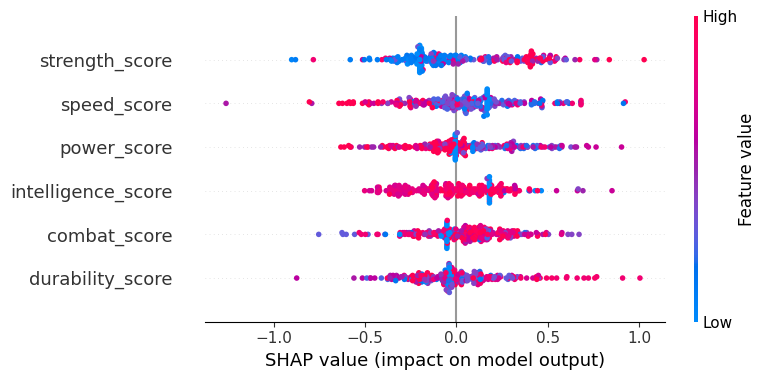

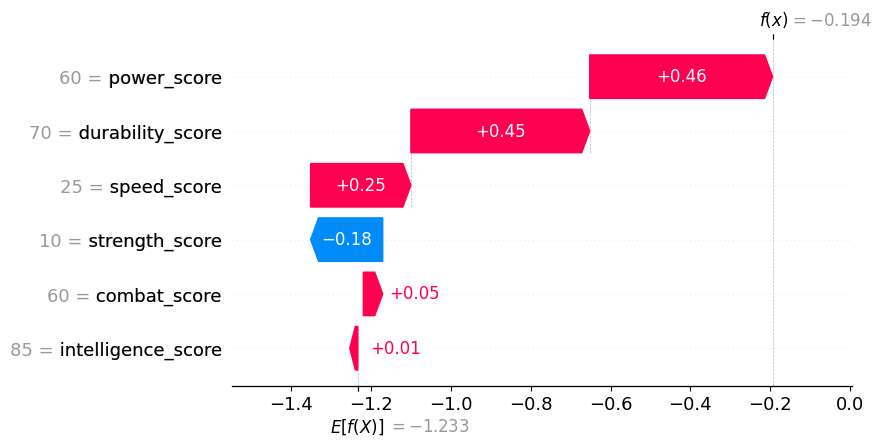

In [41]:
#### Código aquí ####
explainer = shap.TreeExplainer(lgbm_interp)
shap_values = explainer(X_test_num)

# Summary plot para clase "Good" (índice 0 según LabelEncoder)
shap.summary_plot(shap_values[:, :, 0], X_test_num, feature_names=NUMERICAL_FEATURES)

# Waterfall plot para la primera instancia
shap.waterfall_plot(shap_values[0, :, 0])

### 4.2.3 Pregunta de Cierre [0.2 Puntos]

1. ¿Qué diferencia existe entre Permutation Feature Importance y los SHAP values como medida de importancia de features?
2. Según el `waterfall_plot`, ¿qué features fueron las que más empujaron la predicción hacia su clase? Investiga el personaje seleccionado: ¿Tiene sentido dado su historia en los cómics?

> **Respuesta:**

1. PFI mide la importancia global de cada feature para todo el modelo, indicando cuánto baja el rendimiento promedio al permutar esa variable. Los SHAP values en cambio miden la contribución de cada feature para una predicción específica, pudiendo variar de instancia a instancia y siendo positivos o negativos según si empujan hacia o en contra de esa clase.

2. Según el waterfall_plot, las features que más empujaron la predicción hacia la clase Good fueron power_score (+0.46) y durability_score (+0.45), mientras que strength_score (-0.18) fue la única que empujó en contra. El base_value está alrededor de -1.2, lo que indica que el modelo parte con baja probabilidad de predecir Good por defecto, pero los altos valores de power y durability de esta instancia lo empujan hacia esa clase. De todas maneras esto es consistente con el contexto de cómics: personajes buenos suelen tener altos puntajes de poder y durabilidad para enfrentarse a los villanos, mientras que la fuerza bruta no necesariamente define la alineación. El summary_plot confirma esto a nivel global, mostrando que strength_score y speed_score tienen efectos mixtos (puntos tanto rosados como celestes a ambos lados del 0), mientras power_score tiende a tener valores altos (rosados) con SHAP positivo.

---

# 5. Predicción de Personajes No Etiquetados [0.5 Puntos]

<p align="center">
  <img src="https://pbs.twimg.com/media/DolotxUUYAAbg7f.jpg" width="350">
</p>

¡Llegó el momento de predecir `Vergil`, `Gorilla Girl` y `Bat-Cow`!

Usaremos el **mejor modelo** obtenido en la sección 3 (`pipe_lgbm_opt`) para predecir la alineación de los personajes no etiquetados.

**Nota:** Recuerda eliminar los NaN en `history_text` antes de predecir.

### 5.0 Predicción [0.2 Puntos]

**To-do:**
- [ ] Usar `pipe_lgbm_opt` para predecir `alignment` en `df_comics_no_label` (recuerda eliminar NaN en `history_text`).
- [ ] Filtrar y mostrar resultados para `Vergil`, `Gorilla Girl` y `Bat-Cow`.

In [47]:
#### Código aquí ####
df_no_label_clean = df_comics_no_label.dropna(subset=["history_text"])
predicciones_e = pipe_lgbm_opt.predict(df_no_label_clean)
predicciones = le.inverse_transform(predicciones_e)

df_no_label_clean = df_no_label_clean.copy()
df_no_label_clean["alignment_pred"] = predicciones

personajes = ["Gorilla Girl", "Vergil", "Batcow"]
print(df_no_label_clean[df_no_label_clean["name"].isin(personajes)][["name", "alignment_pred"]])

              name alignment_pred
122         Batcow           Good
529   Gorilla Girl           Good
1368        Vergil           Good
122         Batcow           Good


### 5.1 Análisis de Predicciones [0.3 Puntos]

**Pregunta:** Comenta las predicciones obtenidas para `Vergil`, `Gorilla Girl` y `Bat-Cow`:

1. ¿Las predicciones te parecen razonables según lo que conoces (o puedes inferir) de estos personajes?
2. Conecta con la sección 4: ¿qué features numéricas habrían influido más en la predicción de **Bat-Cow** según el `waterfall_plot`? ¿Es consistente con la predicción obtenida aquí?

> **Respuesta:**

1. Los tres personajes son predecidos como Good. Gorilla Girl tiene sentido ya que es una heroína de Marvel que forma parte de los Avengers. Batcow también tiene sentido dado su rol como mascota heroica de Robin en los cómics de Batman, siendo un personaje claramente del lado del bien. Vergil es el más sorprendente ya que es un antihéroe/villano de Devil May Cry conocido por su ambición y enfrentamiento con su hermano Dante, sin embargo su historia tiene matices y momentos donde actúa por razones nobles, lo que podría explicar la predicción.

2. Según el waterfall_plot de la sección 4, power_score (+0.46) y durability_score (+0.45) fueron las features que más empujaron hacia la clase Good. Esto es consistente con la predicción de Batcow: a pesar de ser una vaca, en los cómics tiene superpoderes y es compañera de Robin, lo que implica cierta capacidad de resistencia y poder. El modelo al encontrar valores moderados-altos en estas features tiende a clasificar hacia Good, lo que es coherente con su predicción final.

In [37]:
# Escribe aquí la respuesta

# Conclusión

¡Eso ha sido todo para el lab de hoy! Recuerden que el laboratorio tiene un plazo de entrega de una semana y que **los días de atraso no se pueden utilizar para entregas de lab, solo para tareas**. Cualquier duda del laboratorio, no duden en contactarnos por mail o U-cursos.

<p align="center">
  <img src="https://media1.tenor.com/images/fb5bf7cc5a4acb91b4177672886a88ba/tenor.gif?itemid=5591338">
</p>